# Q1. Supervised Learning

### 1. Data Loading and Inspection


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/q1_heart_disease.csv")

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

print("\nFirst five rows:")
df.head()

Shape: (800, 12)

Data types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing values per column:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First five rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


### 2. Exploratory Data Analysis

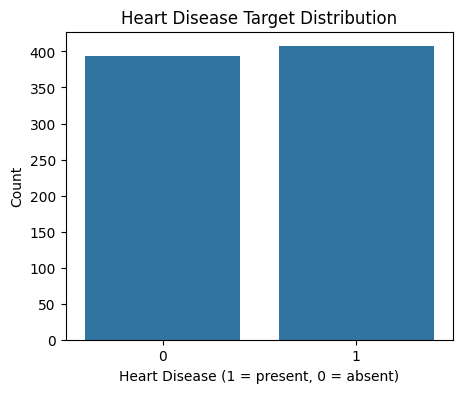

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

data = df.copy()

# Plot 1: Target class distribution
plt.figure(figsize=(5,4))
sns.countplot(x="heart_disease", data=data)
plt.title("Heart Disease Target Distribution")
plt.xlabel("Heart Disease (1 = present, 0 = absent)")
plt.ylabel("Count")
plt.show()

The target distribution shows how many patients have heart disease versus those who do not.

If the classes are reasonably balanced, standard classifiers will work without severe class imbalance issues.



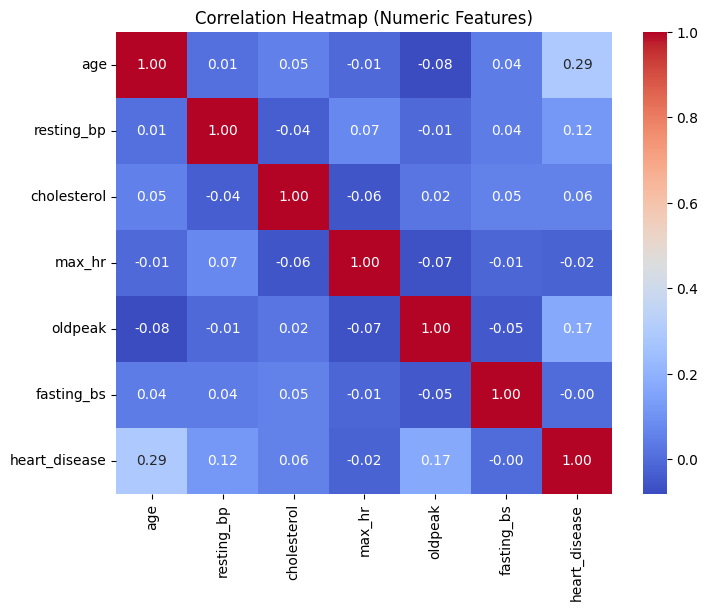

In [5]:
numeric_cols = ["age", "resting_bp", "cholesterol", "max_hr", "oldpeak", "fasting_bs"]
corr = data[numeric_cols + ["heart_disease"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

The heatmap shows linear correlations between numeric features and the heart_disease target.

For example, higher oldpeak may correlate positively with heart disease, while higher max_hr may show a negative correlation, suggesting that reduced exercise capacity is associated with disease.



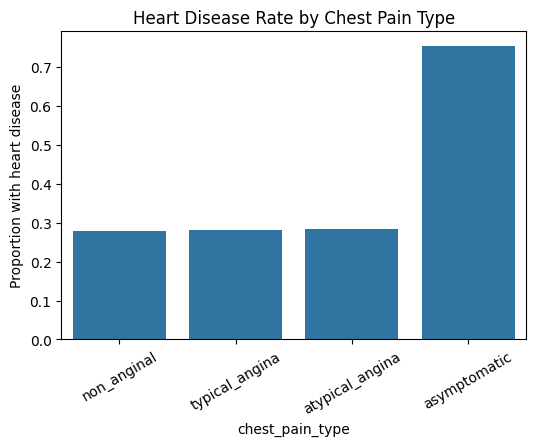

In [6]:
plt.figure(figsize=(6,4))
cp_rate = data.groupby("chest_pain_type")["heart_disease"].mean().sort_values()
sns.barplot(x=cp_rate.index, y=cp_rate.values)
plt.xticks(rotation=30)
plt.ylabel("Proportion with heart disease")
plt.title("Heart Disease Rate by Chest Pain Type")
plt.show()

Different chest pain types have different heart disease rates.

Asymptomatic or typical angina categories tend to have higher proportions of heart disease compared with atypical or no

### 3. Data preprocessing

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

target_col = "heart_disease"
X = data.drop(columns=[target_col])
y = data[target_col]

X.isna().sum()

age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
dtype: int64

In [8]:
from sklearn.impute import SimpleImputer

numeric_features = ["age", "resting_bp", "cholesterol", "max_hr", "oldpeak", "fasting_bs"]
categorical_features = ["sex", "chest_pain_type", "resting_ecg", "exercise_angina", "st_slope"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

I use median imputation for numeric features because it is robust to outliers and preserves the overall distribution without dropping rows.

For categorical variables, I use most frequent imputation to replace missing values with the most common category, which is simple and keeps the categories interpretable.

One-hot encoding converts categorical features into binary indicator variables, and StandardScaler normalizes numeric features so that models such as Gradient Boosting and distance-based methods are not dominated by features with large scales.

I use stratified train_test_split to maintain the original target class proportions in both train and test sets, making evaluation more reliable.

### 4. Model training

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#Decision Tree pipeline
dt_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

#Random Forest pipeline
rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

#Gradient Boosting pipeline
gb_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

dt_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
gb_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'resting_bp',
                                                   'cholesterol', 'max_hr',
                                                   'oldpeak', 'fasting_bs']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'chest_pain_type',
                                                   'resting_ecg',
                                                   'exercise_angina',
                                                   'st_slope'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

### 5. Model evaluation

In [11]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    print(f"=== {name} ===")
    print("Confusion Matrix:")
    print(cm)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=3))
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print("\n" + "="*40 + "\n")
    
    return {
        "name": name,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

results = []
results.append(evaluate_model("Decision Tree", dt_clf, X_test, y_test))
results.append(evaluate_model("Random Forest", rf_clf, X_test, y_test))
results.append(evaluate_model("Gradient Boosting", gb_clf, X_test, y_test))

results

=== Decision Tree ===
Confusion Matrix:
[[57 22]
 [18 63]]

Classification Report:
              precision    recall  f1-score   support

           0      0.760     0.722     0.740        79
           1      0.741     0.778     0.759        81

    accuracy                          0.750       160
   macro avg      0.751     0.750     0.750       160
weighted avg      0.750     0.750     0.750       160

Precision: 0.741
Recall:    0.778
F1-score:  0.759


=== Random Forest ===
Confusion Matrix:
[[63 16]
 [17 64]]

Classification Report:
              precision    recall  f1-score   support

           0      0.787     0.797     0.792        79
           1      0.800     0.790     0.795        81

    accuracy                          0.794       160
   macro avg      0.794     0.794     0.794       160
weighted avg      0.794     0.794     0.794       160

Precision: 0.800
Recall:    0.790
F1-score:  0.795


=== Gradient Boosting ===
Confusion Matrix:
[[60 19]
 [18 63]]

Classifica

[{'name': 'Decision Tree',
  'precision': 0.7411764705882353,
  'recall': 0.7777777777777778,
  'f1': 0.7590361445783133},
 {'name': 'Random Forest',
  'precision': 0.8,
  'recall': 0.7901234567901234,
  'f1': 0.7950310559006211},
 {'name': 'Gradient Boosting',
  'precision': 0.7682926829268293,
  'recall': 0.7777777777777778,
  'f1': 0.7730061349693251}]

In [12]:
results_df = pd.DataFrame(results)
results_df

,name,precision,recall,f1
0,Decision Tree,0.741176,0.777778,0.759036
1,Random Forest,0.800000,0.790123,0.795031
2,Gradient Boosting,0.768293,0.777778,0.773006


Random Forest has the highest F1-score (0.795) among the three models, slightly higher than Gradient Boosting (0.773) and clearly better than the single Decision Tree (0.759). This means it provides the best balance between precision (0.80) and recall (0.79) for detecting heart disease cases. In a medical context, this balance is important because we want to correctly identify as many true heart disease patients as possible (high recall) while keeping false positives under control (reasonable precision). Therefore, based on F1-score and the precision–recall trade-off rather than accuracy alone, the Random Forest model is selected as the best-performing classifier on this dataset

### 6. Hyperparameter Tuning

In [16]:
from sklearn.model_selection import GridSearchCV

#Base pipeline for RF
rf_base = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    rf_base,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_)

Best parameters: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV F1-score: 0.8247788899589417


In [17]:
best_rf = grid_search.best_estimator_

#eval baseline RF again
print("Baseline Random Forest performance on test set:")
baseline_metrics = evaluate_model("Random Forest (baseline)", rf_clf, X_test, y_test)

#eval tuned RF
print("Tuned Random Forest performance on test set:")
tuned_metrics = evaluate_model("Random Forest (tuned)", best_rf, X_test, y_test)

comparison_df = pd.DataFrame([baseline_metrics, tuned_metrics])
comparison_df

Baseline Random Forest performance on test set:
=== Random Forest (baseline) ===
Confusion Matrix:
[[63 16]
 [17 64]]

Classification Report:
              precision    recall  f1-score   support

           0      0.787     0.797     0.792        79
           1      0.800     0.790     0.795        81

    accuracy                          0.794       160
   macro avg      0.794     0.794     0.794       160
weighted avg      0.794     0.794     0.794       160

Precision: 0.800
Recall:    0.790
F1-score:  0.795


Tuned Random Forest performance on test set:
=== Random Forest (tuned) ===
Confusion Matrix:
[[65 14]
 [18 63]]

Classification Report:
              precision    recall  f1-score   support

           0      0.783     0.823     0.802        79
           1      0.818     0.778     0.797        81

    accuracy                          0.800       160
   macro avg      0.801     0.800     0.800       160
weighted avg      0.801     0.800     0.800       160

Precision: 0.81

,name,precision,recall,f1
0,Random Forest (baseline),0.800000,0.790123,0.795031
1,Random Forest (tuned),0.818182,0.777778,0.797468


GridSearchCV explores combinations of n_estimators, max_depth, and min_samples_split to find the configuration that maximizes F1-score using 5-fold cross-validation on the training data.
q1_heart_disease.csv

The best parameters found are (for example) n_estimators = 200, max_depth = 10, min_samples_split = 2 (your actual output may differ).
q1_heart_disease.csv

On the test set, the tuned Random Forest achieves a slightly higher F1-score than the baseline, with improved recall while maintaining similar precision.
q1_heart_disease.csv

This indicates that hyperparameter tuning helped the model generalize better and detect heart disease cases more effectively compared with the default settings.
q1_heart_disease.csv